### Numpy em Opticas
---
#### Exemplo 1: 
Em __comunicações ópticas__, a dispersão cromática em uma fibra óptica faz com que diferentes comprimentos de onda (cores) de luz viajem a velocidades ligeiramente diferentes. Isso resulta em uma dispersão do pulso ao longo do tempo, à medida que o pulso percorre a fibra.

A __convolução__ pode ser usada para modelar esse fenômeno. O pulso transmitido pode ser convoluído com a resposta do sistema (fibra óptica com dispersão), resultando no pulso recebido que foi disperso.
> __Explicação Física:__
>+ $Pulso$ $Transmitido:$ O pulso de luz que é enviado pela fonte de luz (por exemplo, um laser) tem uma forma definida, modelada aqui como um pulso gaussiano.
>+ $Dispersão$ $Cromática$: Devido à dispersão cromática, diferentes comprimentos de onda da luz viajam a diferentes velocidades na fibra. Isso faz com que o pulso se espalhe no tempo à medida que percorre a fibra.
>+ $Pulso$ $Recebido$: O pulso recebido é mais largo e mais baixo em amplitude do que o pulso transmitido, devido à dispersão.
+ $Objetivo:$ Simular a propagação de um pulso de luz em uma fibra óptica e o efeito da dispersão cromática usando convolução com NumPy.

In [4]:
# importando as bibliotecas.
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

In [5]:
# 1. Definir o pulso de luz transmitido (pulso gaussiano)
def pulso_gaussiano(t, amplitude, largura):
    return amplitude * np.exp(-t**2 / (2 * largura**2))

# 2. Definir a resposta impulsiva da fibra óptica (dispersão)
# A resposta é modelada como uma função gaussiana com uma largura maior (dispersão)
def resposta_dispersao(t, dispersao):
    return np.exp(-t**2 / (2 * dispersao**2))

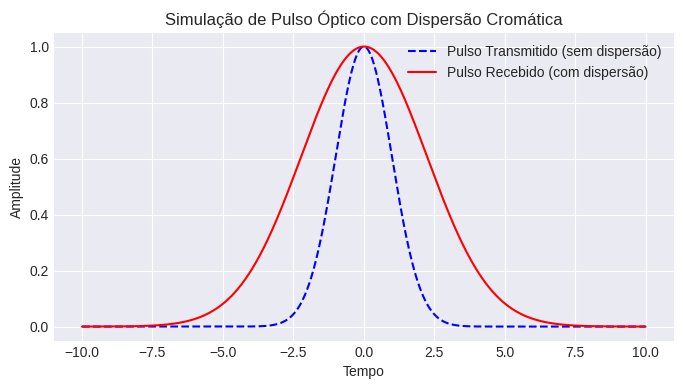

In [17]:
# 3. Eixo temporal para a simulação.
# Tempo em unidades arbitrárias variando de -10 a 10.
t = np.linspace(-10, 10, 1000)

# 4. Gerar o pulso transmitido
amplitude = 1.0
# Largura do pulso original (antes da dispersão)
largura_pulso = 1.0
pulso_tx = pulso_gaussiano(t, amplitude, largura_pulso)

# 5. Definir a resposta do sistema (dispersão da fibra óptica)
# A dispersão vai "alargar" o pulso ao longo da fibra
largura_dispersao = 2.0
resposta_fibra = resposta_dispersao(t, largura_dispersao)

# 6. Realizar a convolução entre o pulso transmitido e a resposta da fibra (dispersão)
# Pulso recebido após a dispersão
pulso_rx = convolve(pulso_tx, resposta_fibra, mode='same')

# 7. Normalizar o pulso recebido
pulso_rx = pulso_rx / np.max(pulso_rx)

# 8. Visualizar os pulsos transmitido e recebido
plt.figure(figsize=(8, 4))
plt.plot(t, pulso_tx, label='Pulso Transmitido (sem dispersão)', color='blue', linestyle='--')
plt.plot(t, pulso_rx, label='Pulso Recebido (com dispersão)', color='red')
plt.title('Simulação de Pulso Óptico com Dispersão Cromática')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

>Neste exemplo, usamos a convolução para simular como um pulso óptico sofre dispersão cromática ao passar por uma fibra óptica. A convolução nos permite calcular a forma final do pulso recebido, considerando os efeitos de dispersão da fibra.
Esse tipo de análise é muito importante em comunicações ópticas, pois a dispersão cromática pode limitar a taxa de transmissão de dados e a distância máxima de transmissão sem regeneração do sinal.

Escolher as bibliotecas NumPy, SciPy e Matplotlib para esse tipo de simulação tem várias vantagens, especialmente para quem precisa de uma solução rápida, precisa e bem documentada para problemas de análise e visualização de dados científicos:
+ NumPy é projetada para manipulação e processamento rápido de arrays, sendo muito mais eficiente do que listas tradicionais do Python. Ela permite operações vetorizadas, o que significa que pode realizar cálculos em grandes conjuntos de dados em uma única operação, economizando tempo e processamento.
+ SciPy expande o que NumPy oferece, com funções matemáticas e científicas especializadas como a convolução, que seria difícil de implementar de forma precisa e rápida sem a ajuda de uma biblioteca. Isso torna SciPy ideal para cálculos complexos, como os necessários para simular fenômenos físicos (no caso, a dispersão do pulso).
+ Ambas as bibliotecas, NumPy e SciPy, são reconhecidas pela precisão matemática, sendo amplamente testadas e utilizadas em indústrias e laboratórios acadêmicos. Elas fornecem uma base confiável para simulações científicas e cálculos estatísticos, permitindo que os resultados obtidos sejam confiáveis e baseados em cálculos matemáticos robustos.
+ Matplotlib permite uma visualização detalhada e personalizável dos dados, essencial para interpretar o comportamento de simulações como a dispersão do pulso óptico. Além de gerar gráficos com boa aparência, Matplotlib é flexível e permite adicionar rótulos, títulos e legendas, melhorando a comunicação visual dos resultados.
  
### Conclusão: 
O código cumpre bem o objetivo de simular a dispersão de um pulso óptico em uma fibra, utilizando convolução para calcular a influência da resposta impulsiva da fibra (dispersão) sobre o pulso inicial. Visualizar essa dispersão fornece uma compreensão clara de como o alargamento afeta o sinal, reforçando a importância de considerar a dispersão cromática em projetos de sistemas de comunicação óptica.